<a href="https://colab.research.google.com/github/2xsec/2xsec.github.io/blob/master/03_RNN_sentiment_classification_ipynb%EC%9D%98_%EC%82%AC%EB%B3%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **순환 신경망(RNN) 실습**

우리가 사용할 데이터는 **IMDB 영화 리뷰 데이터셋**입니다.

이 데이터는
1. 사람들이 작성한 **영화 리뷰 텍스트**와
2. **긍정 혹은 부정**를 나타내는 라벨(Label)로 구성되어 있습니다.
    - 긍정 : 1
    - 부정 : 0


이번 시간은 자연어 처리(NLP)와 RNN(순환 신경망) 모델을 처음 배울 때 많이 다뤄보는 **감정 분류**(**Sentiment Classification**)를 실습합니다.

실제로 감정 분류 작업을 학습/예측 하기에 앞서, 데이터를 어떻게 전처리하는지 먼저 알아봅니다.

# 0. Colab 환경설정
- colab에서 GPU를 사용할 수 있도록 세팅
    - 런타임 > 런타임 유형 변경 > Python 3 와 T4 GPU 선택
- colab에서 Google Drive에 접근할 수 있도록 설정

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("[현재 파일 위치]")
!pwd
print("[현재 디렉토리의 파일 확인]")
!ls

Mounted at /content/drive
[현재 파일 위치]
/content
[현재 디렉토리의 파일 확인]
drive  sample_data


**day 1** 폴더로 이동해주세요.

왼쪽의 **폴더** 아이콘을 클릭하면 경로를 쉽게 볼 수 있습니다.

In [ ]:
# 본인 환경에 맞게 경로를 수정하여 사용하세요.
%cd /content/drive/MyDrive/day1
!pwd

/content/drive/.shortcut-targets-by-id/14tWNTY4XR3u9s_HAqwbH1vpIHSLUipBb/day1
/content/drive/.shortcut-targets-by-id/14tWNTY4XR3u9s_HAqwbH1vpIHSLUipBb/day1


### 0-1. Setup
필요한 package를 import 합니다.

In [ ]:
import random
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


# 1. 데이터
- 모델을 정의하고 학습 및 추론을 진행하기 전, **데이터셋을 불러오고 전처리하는 과정**이 필요합니다.

## 1-1. 데이터셋 불러오기
- `IMDB` 데이터셋은 Train / Test 로 분리되어 있습니다.

In [ ]:
# 먼저 IMDB 데이터셋 압축파일인 `aclImdb_v1.tar.gz`의 압축을 풀어줍니다.
!cp aclImdb_v1.tar.gz /content
!tar -xzf /content/aclImdb_v1.tar.gz -C /content

In [ ]:
from utils_rnn import load_imdb_split

IMDB_ROOT = Path("/content/aclImdb")

# IMDB 데이터셋을 로드합니다.
train_texts, train_labels = load_imdb_split(IMDB_ROOT / "train")
test_texts, test_labels = load_imdb_split(IMDB_ROOT / "test")

print("학습 데이터 크기     :", len(train_texts))
print("테스트 데이터 크기   :", len(test_texts))

# 0 : 부정, 1 : 긍정
label_map = {0: "부정", 1: "긍정"}

# 샘플 데이터를 출력해봅니다.
for i in [10000, 20000]:
    print(f"\n[{i}번 째 샘플]")
    print("문장 :", train_texts[i][:500], "...")
    print("라벨 :", train_labels[i], f"({label_map[train_labels[i]]})")
    print("-" * 80)

학습 데이터 크기     : 25000
테스트 데이터 크기   : 25000

[10000번 째 샘플]
문장 : First, the CGI in this movie was horrible. I watched it during a marathon of bad movies on the SciFi channel. At the end when the owner of the park gets killed, it's probably one of the worst examples of CGI I have even seen. Even Night of the Living Dead had better animation.<br /><br />That said, the movie had almost no plot. Why were they on that island in particular? Well, it wasn't stated in the movie. And, why would the people keep coming into the cat's area? Makes no sense.<br /><br />One ...
라벨 : 0 (부정)
--------------------------------------------------------------------------------

[20000번 째 샘플]
문장 : This Documentary (Now available free on Video.Google.Com) is a fantastic demonstration of the power of ordinary people to overcome injustice. Everyone must see this.<br /><br />Chavez was elected in a landslide vote in 1998. His platform was to divert the fantastic oil wealth from the 20% middle class to the 80% poor.

## 1-1. 자연어 데이터 전처리

자연어처리에서 데이터 전처리는 보통 **원본 텍스트를 모델이 이해할 수 있는 숫자 형태로 인코딩**하는 과정입니다.

토큰마다 id를 부여하여 단어사전을 만들고, 단어사전을 통해 문장을 인코딩할 수 있도록 합니다.

1. **토큰화**
    - `토큰화`란, 문장을 의미 있는 작은 단위인 `토큰`으로 조각내는 작업입니다.
2. (**단어사전 만들기**)
    - 문장을 `토큰화`하고, `토큰`에 대한 `id`를 부여하여 `단어사전`을 만듭니다.
    - **학습 과정에서만** 필요한 작업입니다.
3. **인코딩** :
    - 학습/테스트 데이터를 인코딩합니다.
    - 만들어놓은 단어사전을 참고하여 문장 내의 단어들을 `id`로 대체합니다.

### 1-2-1. 토큰화 (Tokenization)
예시 문장을 토큰화하여 어떤 식으로 토큰화되는지 알아봅니다.

In [ ]:
from utils_rnn import simple_tokenizer

# 예시 문장을 출력해봅니다.
sentence_example = train_texts[0]
print("[원문] :", sentence_example)

###### [실습] sentence_example를 토큰화해보세요. #######
tokens = simple_tokenizer(sentence_example) # sentence_example을 입력하여 토큰화하세요.
print("[토큰] :", tokens)

[원문] : Story of a man who has unnatural feelings for a pig. Starts out with a opening scene that is a terrific example of absurd comedy. A formal orchestra audience is turned into an insane, violent mob by the crazy chantings of it's singers. Unfortunately it stays absurd the WHOLE time with no general narrative eventually making it just too off putting. Even those from the era should be turned off. The cryptic dialogue would make Shakespeare seem easy to a third grader. On a technical level it's better than you might think with some good cinematography by future great Vilmos Zsigmond. Future stars Sally Kirkland and Frederic Forrest can be seen briefly.
[토큰] : ['story', 'of', 'a', 'man', 'who', 'has', 'unnatural', 'feelings', 'for', 'a', 'pig', '.', 'starts', 'out', 'with', 'a', 'opening', 'scene', 'that', 'is', 'a', 'terrific', 'example', 'of', 'absurd', 'comedy', '.', 'a', 'formal', 'orchestra', 'audience', 'is', 'turned', 'into', 'an', 'insane', ',', 'violent', 'mob', 'by', 'the', 

### 1-2-2. 단어사전 만들기

문장은 **단어 사전**(`token_to_id`)을 참고하여 인코딩합니다.  
아직 만들어진 단어 사전이 없기 때문에 만들어야 합니다.

- 자주 등장하는 토큰들의 빈도를 계산하여 각 토큰의 **빈도순으로 정렬**하여 단어 사전을 구성합니다.
    - **많이 등장한 단어일수록 더 중요한 단어**로 간주하기 때문에 빈도순으로 정렬합니다.
    - 너무 희귀한 단어들은 학습에 방해가 되기 때문에 단어사전의 크기를 제한합니다.

- 단어 사전 (`token_to_id`)의 앞부분에는 특수 토큰 `<unk>`와 `<pad>`를 추가합니다.

(단어사전을 만드는 단계는 학습 과정에서만 필요합니다.)

In [ ]:
# 문장을 토큰화하여 단어의 총 빈도 수를 계산합니다.
counter = Counter()
for sentence in train_texts:
    ###### [실습] 문장을 토큰화해보세요. ######
    tokens = simple_tokenizer(sentence)    # 문장 토큰화
    counter.update(tokens)    # 빈도수 세기
token_freq = counter.most_common()


# 먼저 특수 토큰들을 정의합니다.
UNK_TOKEN = "<unk>"     # unknown token
PAD_TOKEN = "<pad>"     # padding token


# (토큰 -> ID)을 매핑하는 dictionary를 생성합니다.
token_to_id = {UNK_TOKEN: 0, PAD_TOKEN: 1}      # 토큰: ID


# 단어 사전의 최대 크기를 설정합니다.
MAX_VOCAB_SIZE = 20002


# 토큰의 빈도순을 기준으로 ID를 할당합니다.
for idx, (token, freq) in enumerate(counter.most_common()):
    # ID는 2부터 시작하도록 합니다. (0: <unk>, 1: <pad>로 이미 할당되어 있기 때문)
    token_id = idx + 2

    ###### [실습] 단어사전에 토큰과 ID를 추가합니다. ######
    token_to_id[token] = token_id
    if len(token_to_id) >= MAX_VOCAB_SIZE:
        break

print("[토큰화된 ID] :", list(token_to_id.items())[:10])
print("\n[전체 토큰 수] :", len(token_to_id))

[토큰화된 ID] : [('<unk>', 0), ('<pad>', 1), ('the', 2), ('.', 3), (',', 4), ('and', 5), ('a', 6), ('of', 7), ('to', 8), ("'", 9)]

[전체 토큰 수] : 20002


### 1-2-2. 데이터 인코딩하기
앞에서 만든 단어사전 \"`token_to_id`\"를 사용하여 **학습/테스트 데이터를 인코딩**합니다.

인코딩 함수 `encode_text`는 다음을 수행합니다.
1. 문장을 토큰화한다.
2. 문장에서 단어사전에 **있는** 토큰은 `해당 토큰의 ID`로 인코딩한다.
3. 문장에서 단어사전에 **없는** 토큰은 `<unk>의 ID`로 인코딩한다.
4. 문장이 너무 길면 `MAX_LENGTH`에 맞춰서 끝을 자른다.
5. 문장이 너무 짧으면 `MAX_LENGTH`에 맞춰서 `<pad>의 ID`를 추가한다.

In [ ]:
from utils_rnn import print_samples
from utils_rnn import encode_text

# 최대 길이를 설정합니다.
MAX_LENGTH = 256

###### [실습] 학습 데이터를 인코딩합니다. ######
train_encoded = []
for sentence in train_texts:
    train_encoded.append(encode_text(sentence, token_to_id, MAX_LENGTH, UNK_TOKEN, PAD_TOKEN))

###### [실습] 테스트 데이터를 인코딩합니다. ######
test_encoded  = []
for sentence in test_texts:
    test_encoded.append(encode_text(sentence, token_to_id, MAX_LENGTH, UNK_TOKEN, PAD_TOKEN))


# 인코딩된 샘플 데이터를 출력해봅니다.
print_samples(random.randint(0, len(train_texts)-1), train_texts, train_encoded, token_to_id, train_labels)
print_samples(random.randint(0, len(test_texts)-1), test_texts, test_encoded, token_to_id, test_labels)

[인덱스]	: 819
[라벨]		: 0
[원문]		: This was a blind buy used DVD. It totally killed a nice buzz I had going when I hit play.<br /><br />It's bubble-headed comedy, but it's um. squalid. The plot is ZANY!, but the characters do things to each other that are so petty and disturbed and conveniently contrived I ultimately found it depressing to watch.<br /><br />Maybe the box lead me to expect something more than an uneven, goofy caper film. (I know, I know, the quotes on the box & the Academy Award nomination mean nothing.)
[토큰]		: ['this', 'was', 'a', 'blind', 'buy', 'used', 'dvd', '.', 'it', 'totally', 'killed', 'a', 'nice', 'buzz', 'i', 'had', 'going', 'when', 'i', 'hit', 'play', '.', 'it', "'", 's', 'bubble', '-', 'headed', 'comedy', ',', 'but', 'it', "'", 's', 'um', '.', '<unk>', '.', 'the', 'plot', 'is', 'zany', '!', ',', 'but', 'the', 'characters', 'do', 'things', 'to', 'each', 'other', 'that', 'are', 'so', 'petty', 'and', 'disturbed', 'and', 'conveniently', 'contrived', 'i', 'ultimately

## 1-3. PyTorch 데이터셋과 DataLoader 만들기
- 데이터를 모델에 입력하는 형태로 만들어봅니다.
- 이를 위해 Pytorch의 `Dataset`, `DataLoader` 클래스를 사용합니다.
- `Dataset`을 상속한 `IMDBDataset`을 통해 데이터셋 형태를 정의합니다.
- `DataLoader`를 통해 데이터를 **배치 단위**로 모델에 입력할 수 있도록 만듭니다.

In [ ]:
# IMDB 데이터셋을 위한 커스텀 Dataset 클래스를 정의합니다.
class IMDBDataset(Dataset):
    def __init__(self, encoded_tokens, labels):
        self.encoded_tokens = encoded_tokens
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        input_id_seq = torch.tensor(self.encoded_tokens[idx], dtype=torch.long)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        return input_id_seq, label

In [ ]:
###### [실습] 인코딩된 데이터와 레이블을 Dataset으로 만듭니다. ######
###### [실습] 위에서 학습 데이터는 `train_encoded`, 테스트 데이터는 `test_encoded`에 저장했었습니다. ######
train_dataset = IMDBDataset(train_encoded, train_labels)
test_dataset  = IMDBDataset(test_encoded,  test_labels)

BATCH_SIZE = 32   # data loader는 배치 단위로 데이터를 로딩하기 위함임

###### [실습] DataLoader를 사용하여 배치 단위로 IMDBDataset을 로드할 수 있도록 합니다. ######
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)


batch_input_id_seq, batch_labels = next(iter(train_loader))
print("입력 shape :", batch_input_id_seq.shape)  # [batch, seq_len]
print("레이블 shape :", batch_labels.shape)   # [batch]

입력 shape : torch.Size([32, 256])
레이블 shape : torch.Size([32])


# 2. RNN (LSTM) 감정 분류 모델

## 2-1. 모델 클래스 정의
이제 감정을 분류할 모델의 클래스를 정의해봅니다.

모델 `LSTMClassifier`은 다음 3단계 구조로 이루어져 있습니다.

1. **Embedding (임베딩 층)**
   - 토큰의 ID를 일정한 길이의 벡터(Vector) 형태로 바꿉니다.
      - 예를 들어, 1004번 단어를 128개의 실수 조합인 `[0.1, -0.4, ..., 0.5]` 형태로 변환합니다.
   - 임베딩 레이어가 잘 학습되면, **의미가 비슷한 단어들은 임베딩 벡터도 비슷해집니다.**
2. **LSTM (Long Short-Term Memory 층)**
   - 대표적인 RNN의 발전된 형태로, 입력된 단어 벡터들을 순서대로 차례차례 읽으며 앞뒤 문맥을 기억합니다.
   - 문장을 전부 읽고 난 뒤, 문맥 정보를 압축한 마지막 출력을 다음 층으로 넘깁니다.
3. **Linear (선형 분류 층)**
   - LSTM이 보내준 문맥 정보를 입력으로 받아 최종적으로 이 문장이 얼마나 긍정적일지 하나의 숫자로 결정합니다.
   - 분류 작업에서 마지막 출력층은 **Classifier**라고 불립니다.

In [ ]:
# LSTM 기반 감성 분류 모델을 정의합니다.
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, pad_id):
        super().__init__()

        ###### [실습] 단어사전의 크기와 임베딩 차원으로 임베딩 레이어를 정의합니다. ######
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim, padding_idx=pad_id)

        # LSTM 레이어를 정의합니다.
        self.lstm = nn.LSTM(
            input_size=embed_dim,           ###### [실습] LSTM에는 embedding이 입력으로 들어갑니다. ######
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
        )

        # 긍정/부정의 이진 분류문제의 출력 차원은 1입니다.
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, input_id_seq):
        # input_id_seq shape: [배치 크기, 문장 길이]

        ###### [실습] 임베딩 레이어로 토큰 ID를 임베딩 벡터로 변환합니다. ######
        embedded = self.embedding(input_id_seq)

        ###### [실습] LSTM 레이어에 임베딩된 입력을 통과시킵니다. ######
        _, (hidden, _) = self.lstm(embedded)


        ###### [실습] 마지막 hidden state만 사용하여 분류할 겁니다. ######
        ###### [실습] hidden[-1]은 hidden의 마지막 요소를 의미합니다. ######
        logits = self.classifier(hidden[-1]).squeeze(1)

        ###### [실습] logits를 반환합니다. ######
        return logits


## 2-2. 모델 및 옵티마이저 초기화
- 정의한 모델 클래스를 객체로 초기화하고 학습 때 사용할 옵티마이저를 정의합니다.

In [ ]:
# 모델의 하이퍼파라미터를 설정합니다.

###### [실습] 앞에서 정의한 단어 사전 'token_to_id'의 크기를 계산합니다. ######
VOCAB_SIZE = len(token_to_id)

# 임베딩 벡터의 크기를 설정합니다.
EMBED_DIM = 128

# LSTM의 hidden state의 차원을 설정합니다.
HIDDEN_DIM = 128

# LSTM의 hidden layer 수를 설정합니다.
NUM_LAYERS = 1


###### [실습] 모델의 하이퍼파라미터를 사용하여 모델을 초기화합니다. ######
model = LSTMClassifier(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    pad_id=token_to_id[PAD_TOKEN]    # 위에서 정의한 PAD_TOKEN을 키로 PAD ID를 사용합니다.
).to(device)


# 옵티마이저를 정의합니다.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


print(model)

LSTMClassifier(
  (embedding): Embedding(20002, 128, padding_idx=1)
  (lstm): LSTM(128, 128, batch_first=True)
  (classifier): Linear(in_features=128, out_features=1, bias=True)
)


# 3. 학습 & 추론

## 3-1. 손실 함수와 평가 지표

이제 **손실 함수**를 정의하여 학습의 목표를 정해야 합니다.

`BCEWithLogitsLoss`는 `logits`을 입력으로 받아 확률값(0% ~ 100%)으로 변환하고 정답(`labels`)과의 오차를 계산합니다.

그리고 `Accuracy`(정확도)라는 "**평가 지표**"을 통해 모델이 얼마나 잘 맞추고 있는지 **사람이 이해할 수 있는 지표**로 만듭니다.
<!--
- 모델의 출력인 `logits`는 아직 확률 형태가 아니기 때문에 확률값(0% ~ 100%)로 변환이 필요합니다.
- `BCEWithLogitsLoss`와 `binary_accuracy_from_logits`는 **확률값으로 변환하는 과정까지** 수행해줍니다. -->

In [ ]:
# 손실 함수를 정의합니다.
loss_function = nn.BCEWithLogitsLoss()

# 예측된 logits과 실제 레이블을 사용하여 정확도를 계산하는 함수를 정의합니다.
def binary_accuracy_from_logits(logits, labels):
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()
    acc = (preds == labels).float().mean()
    return acc.item()

## 3-2. 학습

- 학습 과정과 평가 과정을 정의하여 모델을 학습시킵니다.
- 모델 학습/평가에 필수적인 부분만 psuedo code로 나타내면 다음과 같습니다.

```
for (EPOCH)
    
    for (train_loader)      # 학습 부분
        logits = model(inputs)
        loss = loss_function(logits)
        model_update(loss, labels)
    
    for (test_loader)       # 평가 부분
        logits = model(inputs)
        loss = loss_function(logits)
```

- 위 과정 외 코드는 사람이 이해하기 쉬운 metric을 계산하거나, 학습 과정을 평가하기 위해 기록하는 코드입니다.

In [ ]:
# 모델을 학습하고 평가합니다.

train_losses, train_accs = [], []
test_losses, test_accs = [], []

# 에포크 수를 설정합니다.
EPOCHS = 5

for epoch in range(EPOCHS):
    # ========================================================================
    # 모델을 학습하는 부분입니다.

    # 모델 학습모드
    model.train()
    train_loss = 0.0
    train_acc = 0.0

    # train_loader에서 배치 단위로 데이터를 가져와서 모델을 학습합니다.
    for input_id_seq, labels in train_loader:

        # 배치 데이터를 device로 이동합니다.
        input_id_seq = input_id_seq.to(device)
        labels = labels.to(device)

        # 옵티마이저를 초기화합니다.
        optimizer.zero_grad()

        ###### [실습] train_loader에서 가져온 데이터를 LSTMClassifier에 입력하여 logits를 얻습니다. ######
        ###### [실습] model()은 모델의 forward 함수를 호출합니다. ######
        logits = model(input_id_seq)

        ###### [실습] logits과 labels을 사용하여 loss를 계산합니다. ######
        loss = loss_function(logits, labels)

        # backward와 optimizer step을 수행하여 모델의 파라미터를 업데이트합니다.
        loss.backward()
        optimizer.step()

        ###### [실습] logits과 labels을 사용하여 배치의 정확도를 계산합니다. ######
        acc = binary_accuracy_from_logits(logits, labels)

        # loss를 train_loss에 누적하고, acc를 train_acc에 누적합니다.
        train_loss += loss.item()
        train_acc += acc * 100

    # ========================================================================
    # 모델을 평가하는 부분입니다.

    # 모델 평가모드
    model.eval()
    test_loss = 0.0
    test_acc = 0.0

    with torch.no_grad():
        # test_loader에서 배치 단위로 데이터를 가져와서 모델을 평가합니다.
        for input_id_seq, labels in test_loader:

            # 배치 데이터를 device로 이동합니다.
            input_id_seq = input_id_seq.to(device)
            labels = labels.to(device)

            ###### [실습] test_loader에서 가져온 데이터를 LSTMClassifier에 입력하여 logits를 얻습니다. ######
            ###### [실습] model()은 모델의 forward 함수를 호출합니다. ######
            logits = model(input_id_seq)

            ###### [실습] logits과 labels을 사용하여 loss를 계산합니다. ######
            loss = loss_function(logits, labels)

            ###### [실습] logits과 labels을 사용하여 배치의 정확도를 계산합니다. ######
            acc = binary_accuracy_from_logits(logits, labels)

            # loss를 test_loss에 누적하고, acc를 test_acc에 누적합니다.
            test_loss += loss.item()
            test_acc += acc * 100


    # 각 에포크마다 평균 loss와 정확도를 계산하여 출력합니다.
    train_loss /= len(train_loader)
    train_acc /= len(train_loader)
    test_loss /= len(test_loader)
    test_acc /= len(test_loader)

    print(f"[Epoch {epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
    print("-" * 60)

    # 결과 기록
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

[Epoch 1/5]
Train Loss: 0.6927 | Train Acc: 50.85%
Test Loss: 0.6917 | Test Acc: 51.51%
------------------------------------------------------------
[Epoch 2/5]
Train Loss: 0.6751 | Train Acc: 56.39%
Test Loss: 0.6639 | Test Acc: 60.94%
------------------------------------------------------------
[Epoch 3/5]
Train Loss: 0.6442 | Train Acc: 61.54%
Test Loss: 0.6651 | Test Acc: 63.57%
------------------------------------------------------------
[Epoch 4/5]
Train Loss: 0.6148 | Train Acc: 62.21%
Test Loss: 0.6881 | Test Acc: 58.72%
------------------------------------------------------------
[Epoch 5/5]
Train Loss: 0.5178 | Train Acc: 74.26%
Test Loss: 0.4930 | Test Acc: 78.21%
------------------------------------------------------------


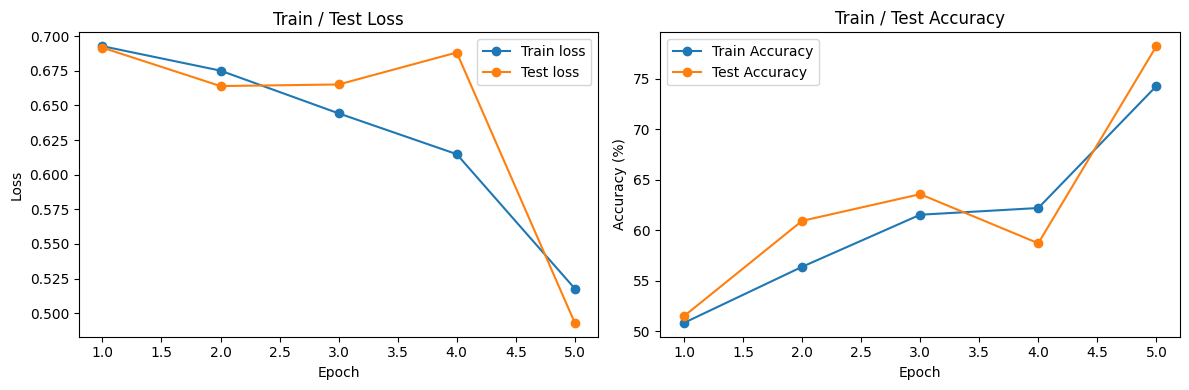

In [ ]:
from utils_rnn import visualize_train_result
visualize_train_result(train_losses, train_accs, test_losses, test_accs, EPOCHS)

## 3-3. 추론

- 이제 실제로 모델이 문장을 잘 분류하는지 눈으로 확인해볼 차례입니다.
- 예시 문장을 사용하거나 본인이 직접 영어로 작성하여 분류 예측을 수행해보세요.

In [ ]:
def predict_sentiment(sentence, model, token_to_id, max_length, device):
    model.eval()

    ###### [실습] 인코딩 함수(encode_text)를 사용하여 문장을 토큰 id로 인코딩합니다. ######
    input_id_seq = encode_text(sentence, token_to_id, max_length, UNK_TOKEN, PAD_TOKEN)

    # 토큰 id를 텐서로 변환하고 디바이스로 이동합니다.
    input_id_seq = torch.tensor(input_id_seq, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        ###### [실습] 데이터를 LSTMClassifier 모델에 입력하여 logits를 얻습니다. ######
        logits = model(input_id_seq)

        # logits을 이용해 확률을 계산합니다.
        probability = torch.sigmoid(logits).item()

    ###### [실습] probability가 50% 이상이면 긍정(1), 그렇지 않으면 부정(0)을 예측합니다. ######
    if probability >= 0.5:
        pred_label = 1
    else:
        pred_label = 0


    return {
        "sentence": sentence,
        "probability": probability,
        "pred_label": pred_label,
    }


# 예시 문장
example_sentences = [
    "This movie was fantastic. I loved every minute of it.",
    "The plot was boring and the acting was terrible."
]


# 예시 문장에 대해 모델의 예측 결과를 출력해봅니다.
for sentence in example_sentences:
    result = predict_sentiment(sentence, model, token_to_id, MAX_LENGTH, device)
    print(f"샘플: {result['sentence']}")
    print(f"예측 결과: \'{result['pred_label']}\' | \'positive\'일 확률: {result['probability']:.4f}")
    print("-" * 80)

샘플: This movie was fantastic. I loved every minute of it.
예측 결과: '1' | 'positive'일 확률: 0.8015
--------------------------------------------------------------------------------
샘플: The plot was boring and the acting was terrible.
예측 결과: '0' | 'positive'일 확률: 0.1137
--------------------------------------------------------------------------------
